In [1]:
import numpy as np
import matplotlib.pyplot as plt


## esto es espectro de energia por region: 700 (hamster)

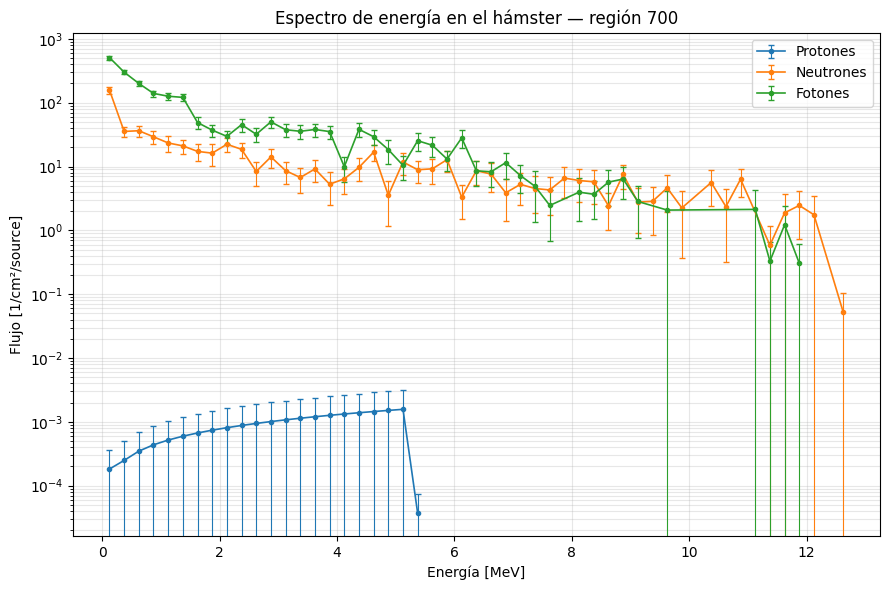

In [3]:
archivo = "energy_hamster_A.out"

particulas = ["Protones", "Neutrones", "Alfas", "Fotones", "Positrones"]

E = []
flujos = {p: [] for p in particulas}
errores = {p: [] for p in particulas}

leyendo = False

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:
        if linea.strip().startswith("#  e-lower"):
            leyendo = True
            continue

        if leyendo and "sum over" in linea.lower():
            break

        if not leyendo:
            continue

        partes = linea.split()

        if len(partes) != 12:
            continue

        try:
            valores = np.array(
                [float(p.replace("D", "E")) for p in partes]
            )
        except ValueError:
            continue

        e1, e2 = valores[:2]
        E.append((e1 + e2) / 2)

        for i, particula in enumerate(particulas):
            flujos[particula].append(valores[2 + 2 * i])
            errores[particula].append(valores[3 + 2 * i])

E = np.array(E)

plt.figure(figsize=(9, 6))

for particula in particulas:
    y = np.array(flujos[particula])
    err = np.array(errores[particula])

    mask = y > 0

    if np.any(mask):
        plt.errorbar(
            E[mask],
            y[mask],
            yerr=y[mask] * err[mask],
            fmt="o-",
            markersize=3,
            linewidth=1.2,
            elinewidth=0.8,
            capsize=2,
            label=particula
        )

plt.yscale("log")

plt.xlabel("Energía [MeV]")
plt.ylabel("Flujo [1/cm²/source]")
plt.title("Espectro de energía en el hámster — región 700")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()